In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/siddharthkhatod/ds-project/criteo-uplift-v2.1.csv


# Stage 0

Loading Criteo Uplift dataset...

--- Data Schema & Shape ---
Row count: 13,979,592 (Expected: 13,979,592)
Columns: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure']

Missing values per column:
f0            0
f1            0
f2            0
f3            0
f4            0
f5            0
f6            0
f7            0
f8            0
f9            0
f10           0
f11           0
treatment     0
conversion    0
visit         0
exposure      0
dtype: int64

--- Base Rates & Sanity Checks ---
Visit Rate:      4.699% (Expected: ~4.13%)
Conversion Rate: 0.292% (Expected: ~0.23%)
Treatment Ratio: 85.000% (Expected: ~84.6%)

--- Plotting Feature Distributions (f0-f11) ---


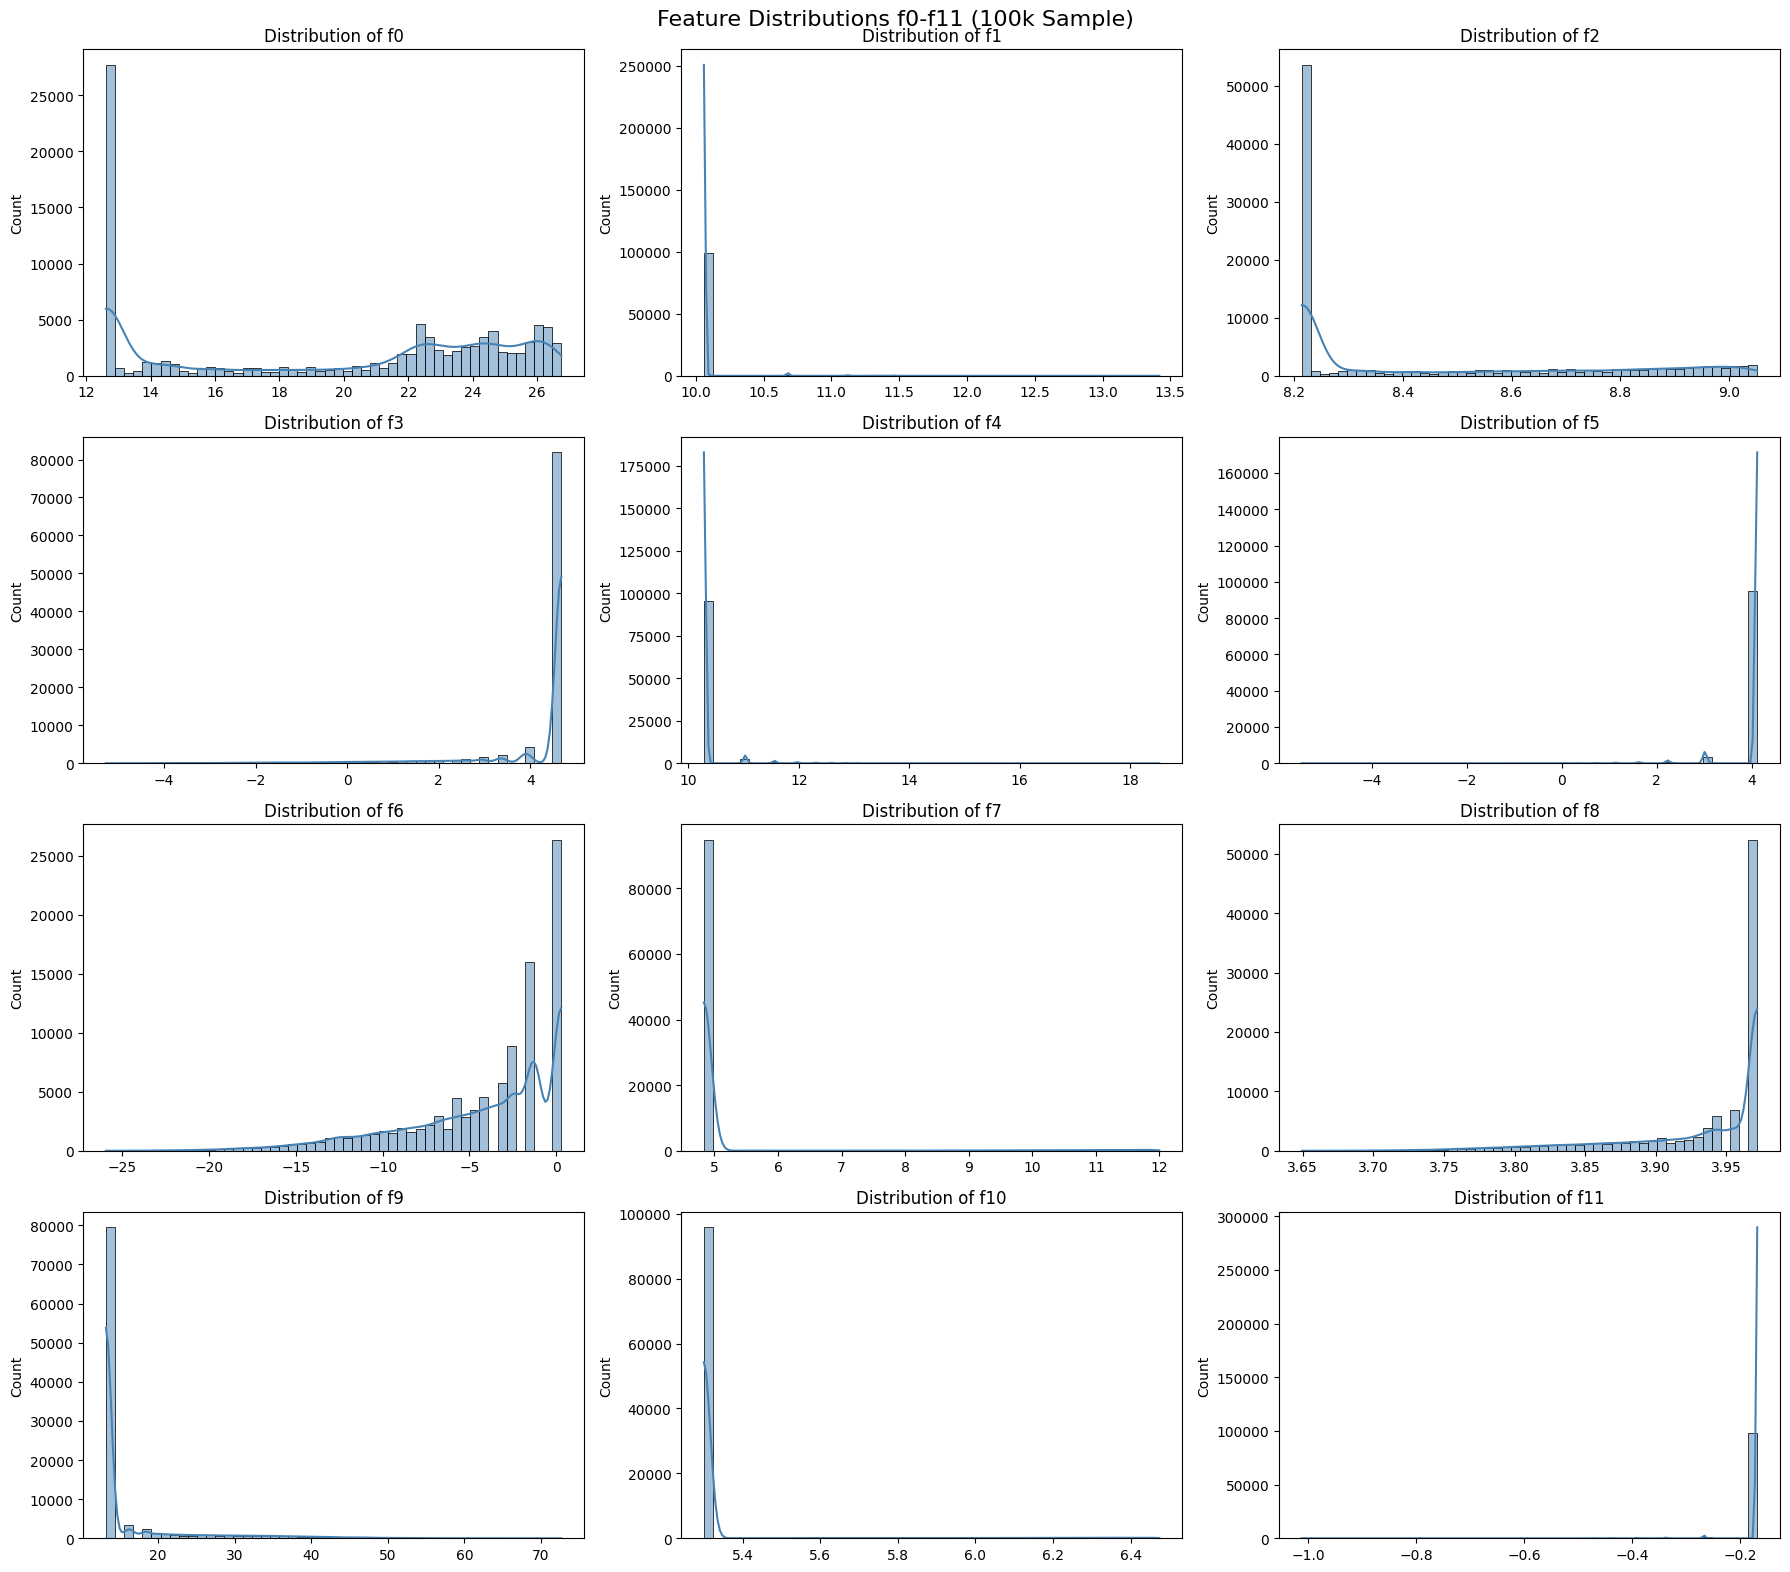

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data using the exact path from your Kaggle input
# file_path = '/kaggle/input/datasets/siddharthkhatod/ds-project/criteo-uplift-v2.1.csv'
# print("Loading Criteo Uplift dataset...")
# df = pd.read_csv(file_path)
file_path = '/kaggle/input/datasets/siddharthkhatod/ds-project/criteo-uplift-v2.1.csv'
print("Loading Criteo Uplift dataset...")
df = pd.read_csv(file_path)

# Downcast to save RAM globally
features = [f'f{i}' for i in range(12)]
df[features] = df[features].astype('float32')
for col in ['treatment', 'conversion', 'visit', 'exposure']:
    df[col] = df[col].astype('int8')

# 2. Confirm schema, row count, and nulls
print("\n--- Data Schema & Shape ---")
print(f"Row count: {df.shape[0]:,} (Expected: 13,979,592)")
print(f"Columns: {list(df.columns)}")
print("\nMissing values per column:")
print(df.isnull().sum())

# 3. Compute and note base rates
print("\n--- Base Rates & Sanity Checks ---")
visit_rate = df['visit'].mean() * 100
conv_rate = df['conversion'].mean() * 100
treatment_ratio = df['treatment'].mean() * 100

print(f"Visit Rate:      {visit_rate:.3f}% (Expected: ~4.13%)")
print(f"Conversion Rate: {conv_rate:.3f}% (Expected: ~0.23%)")
print(f"Treatment Ratio: {treatment_ratio:.3f}% (Expected: ~84.6%)")

# 4. Basic EDA: Distribution plots for f0-f11
print("\n--- Plotting Feature Distributions (f0-f11) ---")
# Note: Plotting 14 million rows is extremely slow and memory-intensive. 
# We take a 100k random sample strictly for visualizing the distributions.
sample_df = df.sample(n=100000, random_state=42) 
features = [f'f{i}' for i in range(12)]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle('Feature Distributions f0-f11 (100k Sample)', fontsize=16)

for i, feature in enumerate(features):
    row, col = divmod(i, 3)
    sns.histplot(sample_df[feature], bins=50, kde=True, ax=axes[row, col], color='steelblue')
    axes[row, col].set_title(f'Distribution of {feature}')
    axes[row, col].set_xlabel('')
    
plt.tight_layout()
plt.show()

# Stage 1

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

print("Starting Phase 0: Randomization & Imbalance Check...\n")

features = [f'f{i}' for i in range(12)]
results = []

# Isolate treatment and control groups
treat_mask = df['treatment'] == 1
df_T = df[treat_mask]
df_C = df[~treat_mask]

n_T = len(df_T)
n_C = len(df_C)

print(f"Treatment N: {n_T:,} | Control N: {n_C:,}\n")

for f in features:
    # 1. Normality/Distribution shape metrics
    skewness = df[f].skew()
    kurtosis = df[f].kurtosis()
    
    t_data = df_T[f]
    c_data = df_C[f]
    
    mean_T = t_data.mean()
    mean_C = c_data.mean()
    std_T = t_data.std()
    std_C = c_data.std()
    
    # 2. Welch's t-test (robust to unequal variances)
    t_stat, p_val = stats.ttest_ind(t_data, c_data, equal_var=False)
    
    # 3. Effect Size: Cohen's d
    pooled_std = np.sqrt(((n_T - 1) * std_T**2 + (n_C - 1) * std_C**2) / (n_T + n_C - 2))
    # Handle zero division just in case a feature is a constant
    cohens_d = (mean_T - mean_C) / pooled_std if pooled_std > 0 else 0
    
    results.append({
        'Feature': f,
        'Skew': skewness,
        'Kurtosis': kurtosis,
        'Mean_C': mean_C,
        'Mean_T': mean_T,
        'p_raw': p_val,
        'Cohens_d': cohens_d
    })

res_df = pd.DataFrame(results)

# 4. Multiple Testing Correction (Benjamini-Hochberg FDR)
res_df['reject_null'], res_df['p_fdr'], _, _ = multipletests(
    res_df['p_raw'], alpha=0.05, method='fdr_bh'
)

# Formatting for clean output
res_df['Cohens_d'] = res_df['Cohens_d'].apply(lambda x: f"{x:.6f}")
res_df['p_fdr'] = res_df['p_fdr'].apply(lambda x: f"{x:.4e}")

# Reorder columns for readability
display_cols = ['Feature', 'Skew', 'Mean_C', 'Mean_T', 'p_fdr', 'reject_null', 'Cohens_d']
print(res_df[display_cols].to_string(index=False))

print("\n--- Imbalance Verdict Analysis ---")
imbalanced = res_df[res_df['reject_null'] == True]
if imbalanced.empty:
    print("Verdict: No statistically significant imbalances found across features after FDR correction.")
else:
    print(f"Verdict: Found {len(imbalanced)} feature(s) with statistically significant differences.")
    print("Note: Even if p_fdr is significant, check Cohen's d. If |d| < 0.01, the difference is practically negligible at this scale.")

Starting Phase 0: Randomization & Imbalance Check...

Treatment N: 11,882,655 | Control N: 2,096,937

Feature       Skew    Mean_C    Mean_T       p_fdr  reject_null  Cohens_d
     f0  -0.245829 19.651701 19.614763  6.4904e-20         True -0.006789
     f1  13.997746 10.067936 10.070338 1.9505e-248         True  0.004830
     f2   0.806385  8.448174  8.446307  1.1996e-16         True -0.004016
     f3  -3.186468  4.232820  4.169413  0.0000e+00         True -0.047221
     f4   8.882762 10.336525 10.339243  1.5430e-26         True  0.003452
     f5  -7.085843  4.039340  4.026601  0.0000e+00         True -0.030344
     f6  -1.135889 -3.999880 -4.182793  0.0000e+00         True -0.040283
     f7   4.524972  5.080285  5.105551 2.8342e-182         True  0.019691
     f8  -1.605565  3.934652  3.933395 2.0262e-199         True -0.015136
     f9   2.822741 15.886253 16.052595 9.2939e-231         True  0.024357
    f10   5.276905  5.331899  5.333660  9.5469e-46         True  0.003534
    f11 -1

# Stage 2

In [4]:
import numpy as np
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest

print("Starting Stage 2: Core A/B Test Evaluation & Power Analysis...\n")

def evaluate_metric(df_T, df_C, metric_name, n_T, n_C):
    x_T = df_T[metric_name].sum()
    x_C = df_C[metric_name].sum()
    
    p_T = x_T / n_T
    p_C = x_C / n_C
    
    abs_lift = p_T - p_C
    rel_lift = (abs_lift / p_C) * 100 if p_C > 0 else 0
    
    # 1. Hypothesis Test (z-stat, p-value) -> Uses POOLED SE
    # proportions_ztest defaults to pooled variance for the test statistic
    count = np.array([x_T, x_C])
    nobs = np.array([n_T, n_C])
    z_stat, p_val = proportions_ztest(count, nobs, alternative='two-sided')
    
    # 2. Confidence Interval (95%) -> Uses UNPOOLED SE
    # We do NOT assume H0 here, so we use the individual group variances
    se_ci_unpooled = np.sqrt((p_T * (1 - p_T) / n_T) + (p_C * (1 - p_C) / n_C))
    z_crit = stats.norm.ppf(0.975) # 95% CI
    ci_lower = abs_lift - z_crit * se_ci_unpooled
    ci_upper = abs_lift + z_crit * se_ci_unpooled
    
    return {
        'p_T': p_T,
        'p_C': p_C,
        'abs_lift': abs_lift,
        'rel_lift': rel_lift,
        'z_stat': z_stat,
        'p_val': p_val,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'se_unpooled': se_ci_unpooled
    }

# 1. Conversion Z-Test
conv_res = evaluate_metric(df_T, df_C, 'conversion', n_T, n_C)

print("--- 1. Conversion Test ---")
print(f"Control Rate (p_C):     {conv_res['p_C']*100:.4f}%")
print(f"Treatment Rate (p_T):   {conv_res['p_T']*100:.4f}%")
print(f"Absolute Lift:          {conv_res['abs_lift']*100:.4f}%")
print(f"Relative Lift:          {conv_res['rel_lift']:.2f}%")
print(f"z-statistic (Pooled):   {conv_res['z_stat']:.4f}")
print(f"p-value (Pooled):       {conv_res['p_val']:.4e}")
print(f"95% CI (Unpooled SE):   [{conv_res['ci_lower']*100:.4f}%, {conv_res['ci_upper']*100:.4f}%]")


# 2. Power Analysis (MDE)
# Standard approximation for MDE: MDE = (z_alpha/2 + z_beta) * sqrt(p_c*(1-p_c)/n_T + p_c*(1-p_c)/n_C)
z_alpha_2 = stats.norm.ppf(0.975)
z_beta = stats.norm.ppf(0.80) # 80% power
p_c_base = conv_res['p_C']

mde_abs = (z_alpha_2 + z_beta) * np.sqrt(p_c_base * (1 - p_c_base) * (1/n_T + 1/n_C))
mde_rel = (mde_abs / p_c_base) * 100

print("\n--- 2. Power Analysis (Conversion) ---")
print(f"Given n_C ≈ {n_C:,}, n_T ≈ {n_T:,}, baseline p_C ≈ {p_c_base*100:.4f}%, Power = 80%, alpha = 0.05:")
print(f"Minimum Detectable Effect (Absolute): {mde_abs*100:.5f}%")
print(f"Minimum Detectable Effect (Relative): {mde_rel:.2f}%")
print(f"\nConclusion: The test was overpowered to detect even trivial effects (a relative lift of just {mde_rel:.2f}%), so failing to reject would have been strong evidence of a true null, not an artifact of insufficient sample size.")


# 3. Visit Z-Test
visit_res = evaluate_metric(df_T, df_C, 'visit', n_T, n_C)

print("\n--- 3. Visit Test (Cross-Validation) ---")
print(f"Control Rate (p_C):     {visit_res['p_C']*100:.4f}%")
print(f"Treatment Rate (p_T):   {visit_res['p_T']*100:.4f}%")
print(f"Absolute Lift:          {visit_res['abs_lift']*100:.4f}%")
print(f"Relative Lift:          {visit_res['rel_lift']:.2f}%")
print(f"z-statistic (Pooled):   {visit_res['z_stat']:.4f}")
print(f"p-value (Pooled):       {visit_res['p_val']:.4e}")
print(f"95% CI (Unpooled SE):   [{visit_res['ci_lower']*100:.4f}%, {visit_res['ci_upper']*100:.4f}%]")

Starting Stage 2: Core A/B Test Evaluation & Power Analysis...

--- 1. Conversion Test ---
Control Rate (p_C):     0.1938%
Treatment Rate (p_T):   0.3089%
Absolute Lift:          0.1152%
Relative Lift:          59.45%
z-statistic (Pooled):   28.5165
p-value (Pooled):       7.3083e-179
95% CI (Unpooled SE):   [0.1085%, 0.1219%]

--- 2. Power Analysis (Conversion) ---
Given n_C ≈ 2,096,937, n_T ≈ 11,882,655, baseline p_C ≈ 0.1938%, Power = 80%, alpha = 0.05:
Minimum Detectable Effect (Absolute): 0.00923%
Minimum Detectable Effect (Relative): 4.76%

Conclusion: The test was overpowered to detect even trivial effects (a relative lift of just 4.76%), so failing to reject would have been strong evidence of a true null, not an artifact of insufficient sample size.

--- 3. Visit Test (Cross-Validation) ---
Control Rate (p_C):     3.8201%
Treatment Rate (p_T):   4.8543%
Absolute Lift:          1.0342%
Relative Lift:          27.07%
z-statistic (Pooled):   65.2474
p-value (Pooled):       0.0000e

# Stage 3

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr

print("Starting Stage 3 | Step 1 & 2: Within-Arm Feature-Outcome Correlations...\n")

features = [f'f{i}' for i in range(12)]
corr_results = []

for f in features:
    # Point-biserial correlation for Treatment
    r_T, _ = pointbiserialr(df_T[f], df_T['conversion'])
    
    # Point-biserial correlation for Control
    r_C, _ = pointbiserialr(df_C[f], df_C['conversion'])
    
    # Calculate divergence
    diff = r_T - r_C
    abs_diff = abs(diff)
    
    corr_results.append({
        'Feature': f,
        'r_Control': r_C,
        'r_Treatment': r_T,
        'Diff (T-C)': diff,
        'Abs_Diff': abs_diff
    })

corr_df = pd.DataFrame(corr_results)

# Sort by the absolute divergence to surface the strongest effect modifiers
corr_df = corr_df.sort_values(by='Abs_Diff', ascending=False).reset_index(drop=True)

# Formatting for readability
corr_df['r_Control'] = corr_df['r_Control'].apply(lambda x: f"{x:.5f}")
corr_df['r_Treatment'] = corr_df['r_Treatment'].apply(lambda x: f"{x:.5f}")
corr_df['Diff (T-C)'] = corr_df['Diff (T-C)'].apply(lambda x: f"{x:.5f}")
corr_df['Abs_Diff'] = corr_df['Abs_Diff'].apply(lambda x: f"{x:.5f}")

print(corr_df.to_string(index=False))

print("\n--- Shortlist Recommendation ---")
top_features = corr_df['Feature'].head(3).tolist()
print(f"Top 3 most divergent features for quantile binning: {top_features}")

Starting Stage 3 | Step 1 & 2: Within-Arm Feature-Outcome Correlations...

Feature r_Control r_Treatment Diff (T-C) Abs_Diff
     f3  -0.07931    -0.10790   -0.02859  0.02859
     f9   0.13449     0.15923    0.02474  0.02474
     f8  -0.11033    -0.13399   -0.02366  0.02366
     f6  -0.05194    -0.07480   -0.02286  0.02286
    f10   0.07857     0.10129    0.02272  0.02272
     f4   0.28216     0.30283    0.02067  0.02067
     f5  -0.07283    -0.08828   -0.01545  0.01545
     f7   0.03164     0.04537    0.01373  0.01373
    f11  -0.30517    -0.31721   -0.01204  0.01204
     f0  -0.02928    -0.03941   -0.01013  0.01013
     f1   0.07578     0.08393    0.00815  0.00815
     f2  -0.01230    -0.01446   -0.00216  0.00216

--- Shortlist Recommendation ---
Top 3 most divergent features for quantile binning: ['f3', 'f9', 'f8']


In [6]:
import numpy as np
import scipy.stats as stats

print("Starting Stage 3 | Step 3: Quantile Binning & Per-Bin ATE...\n")
shortlist = ['f3', 'f9', 'f8']
z_crit = stats.norm.ppf(0.975)

for feature in shortlist:
    print(f"--- Quantile Analysis: {feature} ---")
    
    # Use qcut to create quintiles. 
    # duplicates='drop' is crucial here because Criteo's skewed features often have heavy point masses
    df['bin'] = pd.qcut(df[feature], q=5, duplicates='drop')
    bins = sorted(df['bin'].unique())
    
    for b in bins:
        bin_mask = df['bin'] == b
        df_bin = df[bin_mask]
        
        df_T_bin = df_bin[df_bin['treatment'] == 1]
        df_C_bin = df_bin[df_bin['treatment'] == 0]
        
        n_T_bin = len(df_T_bin)
        n_C_bin = len(df_C_bin)
        
        # Guardrail for empty bins
        if n_T_bin == 0 or n_C_bin == 0:
            continue
            
        p_T = df_T_bin['conversion'].sum() / n_T_bin
        p_C = df_C_bin['conversion'].sum() / n_C_bin
        
        ate = p_T - p_C
        
        # Unpooled SE explicitly for the CI calculation within this specific bin
        se = np.sqrt((p_T * (1 - p_T) / n_T_bin) + (p_C * (1 - p_C) / n_C_bin))
        ci_lower = ate - z_crit * se
        ci_upper = ate + z_crit * se
        
        print(f"Bin {b}: ATE = {ate*100:.4f}% | 95% CI [{ci_lower*100:.4f}%, {ci_upper*100:.4f}%] | N_T={n_T_bin:,}, N_C={n_C_bin:,}")
    print("\n")

Starting Stage 3 | Step 3: Quantile Binning & Per-Bin ATE...

--- Quantile Analysis: f3 ---
Bin (-8.399, 4.68]: ATE = 0.1152% | 95% CI [0.1085%, 0.1219%] | N_T=11,882,655, N_C=2,096,937


--- Quantile Analysis: f9 ---
Bin (13.189, 16.226]: ATE = 0.0169% | 95% CI [0.0142%, 0.0195%] | N_T=9,821,021, N_C=1,747,126
Bin (16.226, 75.295]: ATE = 0.5446% | 95% CI [0.5069%, 0.5822%] | N_T=2,061,634, N_C=349,811


--- Quantile Analysis: f8 ---
Bin (3.634, 3.893]: ATE = 0.4821% | 95% CI [0.4496%, 0.5146%] | N_T=2,436,072, N_C=412,734
Bin (3.893, 3.944]: ATE = 0.0310% | 95% CI [0.0236%, 0.0384%] | N_T=2,434,033, N_C=437,429
Bin (3.944, 3.972]: ATE = 0.0047% | 95% CI [0.0029%, 0.0064%] | N_T=7,012,550, N_C=1,246,774




Starting Validation & Train/Test Split...

Data split complete. No further exploration on the 2,795,919 test rows.
Train size: 11,183,673 | Test size: 2,795,919

--- Plotting f9 Distribution (Train Set) ---


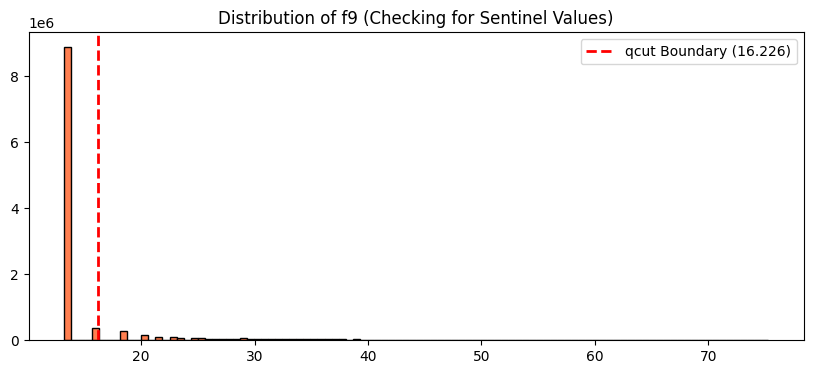

--- Holdout Validation: Re-evaluating on 20% Test Split ---
[f9] Lower Bin       (Condition: f9 <= 16.226)
  ATE = 0.0200% | 95% CI [0.0148%, 0.0253%]
  N_T = 1,886,791 | N_C = 335,743

[f9] Upper Bin       (Condition: f9 > 16.226)
  ATE = 0.4946% | 95% CI [0.4232%, 0.5659%]
  N_T = 489,741 | N_C = 83,644

[f8] Low Bin         (Condition: f8 <= 3.893)
  ATE = 0.5199% | 95% CI [0.4475%, 0.5923%]
  N_T = 486,609 | N_C = 82,548

[f8] Mid Bin         (Condition: f8 > 3.893 and f8 <= 3.944)
  ATE = 0.0290% | 95% CI [0.0124%, 0.0457%]
  N_T = 487,699 | N_C = 87,595

[f8] High Bin        (Condition: f8 > 3.944)
  ATE = 0.0072% | 95% CI [0.0038%, 0.0106%]
  N_T = 1,402,224 | N_C = 249,244



In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split

print("Starting Validation & Train/Test Split...\n")

# 1. Carve out the clean test split (80/20) - Stratified by treatment
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['treatment'])
print(f"Data split complete. No further exploration on the {len(df_test):,} test rows.")
print(f"Train size: {len(df_train):,} | Test size: {len(df_test):,}\n")

# 2. Check f9 for Sentinel Values / Point Mass
print("--- Plotting f9 Distribution (Train Set) ---")
plt.figure(figsize=(10, 4))
# Zooming in heavily on the bins to find the spike
plt.hist(df_train['f9'], bins=100, color='coral', edgecolor='black')
plt.axvline(16.226, color='red', linestyle='dashed', linewidth=2, label='qcut Boundary (16.226)')
plt.title('Distribution of f9 (Checking for Sentinel Values)')
plt.legend()
plt.show()

# 3. Holdout Validation on f9 and f8
z_crit = stats.norm.ppf(0.975)

def evaluate_holdout_bin(df_split, feature_name, condition, bin_label):
    df_bin = df_split.query(condition)
    df_T_bin = df_bin[df_bin['treatment'] == 1]
    df_C_bin = df_bin[df_bin['treatment'] == 0]
    
    n_T = len(df_T_bin)
    n_C = len(df_C_bin)
    
    # Guardrail
    if n_T == 0 or n_C == 0:
        print(f"[{feature_name} | {bin_label}]: Insufficient N")
        return
        
    p_T = df_T_bin['conversion'].sum() / n_T
    p_C = df_C_bin['conversion'].sum() / n_C
    
    ate = p_T - p_C
    se = np.sqrt((p_T * (1 - p_T) / n_T) + (p_C * (1 - p_C) / n_C))
    ci_lower = ate - z_crit * se
    ci_upper = ate + z_crit * se
    
    print(f"[{feature_name}] {bin_label: <15} (Condition: {condition})")
    print(f"  ATE = {ate*100:.4f}% | 95% CI [{ci_lower*100:.4f}%, {ci_upper*100:.4f}%]")
    print(f"  N_T = {n_T:,} | N_C = {n_C:,}\n")

print("--- Holdout Validation: Re-evaluating on 20% Test Split ---")

# Using the exact cutoffs from your Stage 3 screenshot
evaluate_holdout_bin(df_test, 'f9', 'f9 <= 16.226', 'Lower Bin')
evaluate_holdout_bin(df_test, 'f9', 'f9 > 16.226', 'Upper Bin')

evaluate_holdout_bin(df_test, 'f8', 'f8 <= 3.893', 'Low Bin')
evaluate_holdout_bin(df_test, 'f8', 'f8 > 3.893 and f8 <= 3.944', 'Mid Bin')
evaluate_holdout_bin(df_test, 'f8', 'f8 > 3.944', 'High Bin')

In [8]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split

print("--- Fixing Data Hygiene: The 3-Way Split ---")
# 1. The previous 'df_test' is now our Validation set
df_val = df_test.copy()

# 2. Carve a pristine Test set out of df_train (reserving ~20% of the overall data)
# df_train currently holds 80%. Splitting it 75/25 yields a 60/20/20 overall split.
df_train_clean, df_test_clean = train_test_split(
    df_train, test_size=0.25, random_state=42, stratify=df_train['treatment']
)

print("Final Data Splits Lineage:")
print(f"Train (Clean):       {len(df_train_clean):,} rows (for meta-learner training)")
print(f"Validation (Burned): {len(df_val):,} rows (for early stopping / hyper-params)")
print(f"Test (Pristine):     {len(df_test_clean):,} rows (LOCKED until Stage 6/7 Qini)\n")

print("--- Stage 4: S-Learner Diagnostic ---")
features = [f'f{i}' for i in range(12)]
X_train = df_train_clean[features + ['treatment']]
y_train = df_train_clean['conversion']

print("Training LightGBM S-Learner (Single Model)...")
# Using standard defaults to check raw feature dominance
s_learner = lgb.LGBMClassifier(
    n_estimators=100, 
    learning_rate=0.05, 
    random_state=42,
    n_jobs=-1
)
s_learner.fit(X_train, y_train)

# Pull gain-based feature importance
importance_scores = s_learner.booster_.feature_importance(importance_type='gain')
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Gain': importance_scores
}).sort_values(by='Gain', ascending=False).reset_index(drop=True)

# Normalize gain to percentages
feat_imp['Gain_Pct'] = (feat_imp['Gain'] / feat_imp['Gain'].sum()) * 100

print("\nFeature Importance (Gain):")
print(feat_imp.to_string(index=False, float_format="%.2f"))

treat_rank = feat_imp[feat_imp['Feature'] == 'treatment'].index[0] + 1
treat_gain = feat_imp[feat_imp['Feature'] == 'treatment']['Gain_Pct'].values[0]

print(f"\n--- Diagnostic Result ---")
print(f"Treatment Feature Rank: {treat_rank} out of {len(X_train.columns)}")
print(f"Treatment Gain Share:   {treat_gain:.2f}%")

--- Fixing Data Hygiene: The 3-Way Split ---
Final Data Splits Lineage:
Train (Clean):       8,387,754 rows (for meta-learner training)
Validation (Burned): 2,795,919 rows (for early stopping / hyper-params)
Test (Pristine):     2,795,919 rows (LOCKED until Stage 6/7 Qini)

--- Stage 4: S-Learner Diagnostic ---
Training LightGBM S-Learner (Single Model)...
[LightGBM] [Info] Number of positive: 24357, number of negative: 8363397
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.475285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1701
[LightGBM] [Info] Number of data points in the train set: 8387754, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.002904 -> initscore=-5.838801
[LightGBM] [Info] Start training from score -5.838801

Feature Importance (Gain):
  Feature       Gain  Gain_Pct
       f6 1688175.05

In [9]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, log_loss

print("--- Stage 4: T-Learner Training & Diagnostics ---\n")

features = [f'f{i}' for i in range(12)]

# 1. Isolate Treated and Control sets in Train and Val
df_train_T = df_train_clean[df_train_clean['treatment'] == 1]
df_train_C = df_train_clean[df_train_clean['treatment'] == 0]

df_val_T = df_val[df_val['treatment'] == 1]
df_val_C = df_val[df_val['treatment'] == 0]

# 2. Fit independent LightGBM models
lgb_params = {
    'n_estimators': 100, 
    'learning_rate': 0.05, 
    'random_state': 42,
    'n_jobs': -1
}

print(f"Training model_treat on N={len(df_train_T):,}...")
model_treat = lgb.LGBMClassifier(**lgb_params)
model_treat.fit(df_train_T[features], df_train_T['conversion'])

print(f"Training model_control on N={len(df_train_C):,}...\n")
model_control = lgb.LGBMClassifier(**lgb_params)
model_control.fit(df_train_C[features], df_train_C['conversion'])

# 3. Diagnostic: Train vs. Val Gap (Overfitting Check)
def get_metrics(model, X, y):
    preds = model.predict_proba(X)[:, 1]
    return roc_auc_score(y, preds), log_loss(y, preds)

# Treated Model Metrics
auc_train_T, ll_train_T = get_metrics(model_treat, df_train_T[features], df_train_T['conversion'])
auc_val_T, ll_val_T = get_metrics(model_treat, df_val_T[features], df_val_T['conversion'])

# Control Model Metrics
auc_train_C, ll_train_C = get_metrics(model_control, df_train_C[features], df_train_C['conversion'])
auc_val_C, ll_val_C = get_metrics(model_control, df_val_C[features], df_val_C['conversion'])

print("--- Overfitting Diagnostic: Train-Val Gap ---")
print(f"Model Treat   | Train AUC: {auc_train_T:.4f} | Val AUC: {auc_val_T:.4f} | Gap: {auc_train_T - auc_val_T:.4f}")
print(f"Model Control | Train AUC: {auc_train_C:.4f} | Val AUC: {auc_val_C:.4f} | Gap: {auc_train_C - auc_val_C:.4f}")
print("-" * 75)
print(f"Model Treat   | Train LogLoss: {ll_train_T:.4f} | Val LogLoss: {ll_val_T:.4f} | Gap: {ll_val_T - ll_train_T:.4f}")
print(f"Model Control | Train LogLoss: {ll_train_C:.4f} | Val LogLoss: {ll_val_C:.4f} | Gap: {ll_val_C - ll_train_C:.4f}\n")

# 4. Secondary Check: Predicted CATE vs Known Heterogeneity
print("--- Secondary Check: T-Learner CATE vs f8/f9 Bins ---")

# Predict both factual and counterfactual outcomes for the validation set
preds_T = model_treat.predict_proba(df_val[features])[:, 1]
preds_C = model_control.predict_proba(df_val[features])[:, 1]

df_val_cate = df_val.copy()
df_val_cate['cate_pred'] = preds_T - preds_C

# Evaluate f9 sentinel behavior
f9_low_cate = df_val_cate[df_val_cate['f9'] <= 16.226]['cate_pred'].mean() * 100
f9_high_cate = df_val_cate[df_val_cate['f9'] > 16.226]['cate_pred'].mean() * 100

# Evaluate f8 monotonic gradient
f8_low_cate = df_val_cate[df_val_cate['f8'] <= 3.893]['cate_pred'].mean() * 100
f8_mid_cate = df_val_cate[(df_val_cate['f8'] > 3.893) & (df_val_cate['f8'] <= 3.944)]['cate_pred'].mean() * 100
f8_high_cate = df_val_cate[df_val_cate['f8'] > 3.944]['cate_pred'].mean() * 100

print(f"[f9] Lower Bin (<= 16.226) Mean Predicted CATE: {f9_low_cate:.4f}% (Expected: ~0.02%)")
print(f"[f9] Upper Bin (> 16.226)  Mean Predicted CATE: {f9_high_cate:.4f}% (Expected: ~0.49%)")
print("-" * 50)
print(f"[f8] Low Bin (<= 3.893)    Mean Predicted CATE: {f8_low_cate:.4f}% (Expected: ~0.51%)")
print(f"[f8] Mid Bin               Mean Predicted CATE: {f8_mid_cate:.4f}% (Expected: ~0.02%)")
print(f"[f8] High Bin (> 3.944)    Mean Predicted CATE: {f8_high_cate:.4f}% (Expected: ~0.007%)")

--- Stage 4: T-Learner Training & Diagnostics ---

Training model_treat on N=7,129,592...
[LightGBM] [Info] Number of positive: 21905, number of negative: 7107687
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.439000 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1702
[LightGBM] [Info] Number of data points in the train set: 7129592, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.003072 -> initscore=-5.782217
[LightGBM] [Info] Start training from score -5.782217
Training model_control on N=1,258,162...

[LightGBM] [Info] Number of positive: 2452, number of negative: 1255710
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053840 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGB


X learner

In [10]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split

print("--- Stage 4: X-Learner Build & Stability Diagnostic ---\n")

features = [f'f{i}' for i in range(12)]
effect_params = {
    'n_estimators': 100, 
    'learning_rate': 0.05, 
    'random_state': 42,
    'n_jobs': -1
}

# 1. Compute Imputed Treatment Effects (D)
print("Step 1: Computing imputed treatment effects (D)...")
preds_treat_on_control = model_treat.predict_proba(df_train_C[features])[:, 1]
D_control = preds_treat_on_control - df_train_C['conversion']

preds_control_on_treat = model_control.predict_proba(df_train_T[features])[:, 1]
D_treat = df_train_T['conversion'] - preds_control_on_treat

# 2. Fit Stage 2 Models (Effect Models)
print("Step 2: Fitting Stage 2 effect models (Regressors)...")
model_effect_control = lgb.LGBMRegressor(**effect_params)
model_effect_control.fit(df_train_C[features], D_control)

model_effect_treat = lgb.LGBMRegressor(**effect_params)
model_effect_treat.fit(df_train_T[features], D_treat)

# 3. Fit Propensity Model P(T=1 | X)
print("Step 3: Fitting Propensity Model P(T=1 | X)...")
prop_model = lgb.LGBMClassifier(**effect_params)
prop_model.fit(df_train_clean[features], df_train_clean['treatment'])

# Gut-check propensity scores against baseline (85%)
val_prop_scores = prop_model.predict_proba(df_val[features])[:, 1]
print(f"  -> Mean Validation Propensity Score: {val_prop_scores.mean():.4f} (Expected: ~0.85)")

# 4. Final CATE Function
def predict_x_learner_cate(X):
    eff_C = model_effect_control.predict(X)
    eff_T = model_effect_treat.predict(X)
    g_x = prop_model.predict_proba(X)[:, 1]
    
    # Weighting is inverted: weight toward the arm-effect-model trained on the opposite group
    return g_x * eff_C + (1 - g_x) * eff_T

# 5. Stability Diagnostic (cross_effect_stability)
print("\n--- Diagnostic: CATE Variance across Subsamples (T vs X) ---")
print("Refitting T and X learners on 3 random 50% subsamples to measure stability...")

n_iterations = 3
t_cate_preds = []
x_cate_preds = []

# Using a 100k sample of validation data to keep the variance computation fast
df_val_sample = df_val.sample(n=100000, random_state=42)
X_val_samp = df_val_sample[features]

for i in range(n_iterations):
    print(f"  Iteration {i+1}/{n_iterations}...")
    
    # 50% random subsample of train data
    sub_train = df_train_clean.sample(frac=0.5, random_state=i)
    sub_T = sub_train[sub_train['treatment'] == 1]
    sub_C = sub_train[sub_train['treatment'] == 0]
    
    # T-Learner Refit
    m_t = lgb.LGBMClassifier(**effect_params).fit(sub_T[features], sub_T['conversion'])
    m_c = lgb.LGBMClassifier(**effect_params).fit(sub_C[features], sub_C['conversion'])
    
    t_pred = m_t.predict_proba(X_val_samp)[:, 1] - m_c.predict_proba(X_val_samp)[:, 1]
    t_cate_preds.append(t_pred)
    
    # X-Learner Refit (Stage 2 + Propensity)
    d_c = m_t.predict_proba(sub_C[features])[:, 1] - sub_C['conversion']
    d_t = sub_T['conversion'] - m_c.predict_proba(sub_T[features])[:, 1]
    
    m_eff_c = lgb.LGBMRegressor(**effect_params).fit(sub_C[features], d_c)
    m_eff_t = lgb.LGBMRegressor(**effect_params).fit(sub_T[features], d_t)
    
    m_prop = lgb.LGBMClassifier(**effect_params).fit(sub_train[features], sub_train['treatment'])
    gx = m_prop.predict_proba(X_val_samp)[:, 1]
    
    x_pred = gx * m_eff_c.predict(X_val_samp) + (1 - gx) * m_eff_t.predict(X_val_samp)
    x_cate_preds.append(x_pred)

# Compute per-user variance across iterations, then take the mean
t_var = np.var(np.column_stack(t_cate_preds), axis=1).mean()
x_var = np.var(np.column_stack(x_cate_preds), axis=1).mean()

print("\n--- Stability Results ---")
print(f"Mean CATE Variance (T-Learner): {t_var:.8e}")
print(f"Mean CATE Variance (X-Learner): {x_var:.8e}")

if x_var < t_var:
    reduction = ((t_var - x_var) / t_var) * 100
    print(f"Verdict: X-Learner successfully reduced prediction variance by {reduction:.1f}%.")
    print("This empirically proves the cross-imputation step stabilized the counterfactual estimates.")
else:
    print("Verdict: X-Learner did not improve stability over T-Learner on this dataset.")

--- Stage 4: X-Learner Build & Stability Diagnostic ---

Step 1: Computing imputed treatment effects (D)...
Step 2: Fitting Stage 2 effect models (Regressors)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1699
[LightGBM] [Info] Number of data points in the train set: 1258162, number of used features: 12
[LightGBM] [Info] Start training from score 0.000893
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.406419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1702
[LightGBM] [Info] Number of data points in the train set: 7129592, number of used features: 12
[LightGBM] [Info] Start training from score 0.000902
Step 3: Fitting Propen

In [11]:
import numpy as np
import pandas as pd
import lightgbm as lgb

print("--- Stage 5: Rigorous X-Learner Validation ---\n")

# 1. 3-Way Stability & Range Diagnostic
print("Running 3-Way Stability & Range Diagnostic across 3 subsamples...")
n_iterations = 3
s_cate_preds, t_cate_preds, x_cate_preds = [], [], []

for i in range(n_iterations):
    print(f"  Iteration {i+1}/{n_iterations}...")
    sub_train = df_train_clean.sample(frac=0.5, random_state=i)
    sub_T = sub_train[sub_train['treatment'] == 1]
    sub_C = sub_train[sub_train['treatment'] == 0]
    
    # S-Learner Refit
    m_s = lgb.LGBMClassifier(**effect_params).fit(sub_train[features + ['treatment']], sub_train['conversion'])
    X_val_T = df_val_sample[features].copy(); X_val_T['treatment'] = 1
    X_val_C = df_val_sample[features].copy(); X_val_C['treatment'] = 0
    s_pred = m_s.predict_proba(X_val_T)[:, 1] - m_s.predict_proba(X_val_C)[:, 1]
    s_cate_preds.append(s_pred)
    
    # T-Learner Refit (from previous block)
    m_t = lgb.LGBMClassifier(**effect_params).fit(sub_T[features], sub_T['conversion'])
    m_c = lgb.LGBMClassifier(**effect_params).fit(sub_C[features], sub_C['conversion'])
    t_pred = m_t.predict_proba(df_val_sample[features])[:, 1] - m_c.predict_proba(df_val_sample[features])[:, 1]
    t_cate_preds.append(t_pred)
    
    # X-Learner Refit (from previous block)
    d_c = m_t.predict_proba(sub_C[features])[:, 1] - sub_C['conversion']
    d_t = sub_T['conversion'] - m_c.predict_proba(sub_T[features])[:, 1]
    m_eff_c = lgb.LGBMRegressor(**effect_params).fit(sub_C[features], d_c)
    m_eff_t = lgb.LGBMRegressor(**effect_params).fit(sub_T[features], d_t)
    m_prop = lgb.LGBMClassifier(**effect_params).fit(sub_train[features], sub_train['treatment'])
    gx = m_prop.predict_proba(df_val_sample[features])[:, 1]
    x_pred = gx * m_eff_c.predict(df_val_sample[features]) + (1 - gx) * m_eff_t.predict(df_val_sample[features])
    x_cate_preds.append(x_pred)

def get_stats(preds_list):
    arr = np.column_stack(preds_list)
    return np.var(arr, axis=1).mean(), arr.mean(), arr.min(), arr.max()

s_var, s_mean, s_min, s_max = get_stats(s_cate_preds)
t_var, t_mean, t_min, t_max = get_stats(t_cate_preds)
x_var, x_mean, x_min, x_max = get_stats(x_cate_preds)

print("\n--- 3-Way Stability & Range Results ---")
print(f"S-Learner | Var: {s_var:.8e} | Mean: {s_mean*100:.4f}% | Range: [{s_min*100:.4f}%, {s_max*100:.4f}%]")
print(f"T-Learner | Var: {t_var:.8e} | Mean: {t_mean*100:.4f}% | Range: [{t_min*100:.4f}%, {t_max*100:.4f}%]")
print(f"X-Learner | Var: {x_var:.8e} | Mean: {x_mean*100:.4f}% | Range: [{x_min*100:.4f}%, {x_max*100:.4f}%]")

# 2. X-Learner Bin Recovery Check (Using primary X-learner model on full validation set)
print("\n--- X-Learner: Secondary Check on f8/f9 Bins ---")
df_val_cate_X = df_val.copy()
df_val_cate_X['cate_pred_X'] = predict_x_learner_cate(df_val[features])

f9_low_cate_X = df_val_cate_X[df_val_cate_X['f9'] <= 16.226]['cate_pred_X'].mean() * 100
f9_high_cate_X = df_val_cate_X[df_val_cate_X['f9'] > 16.226]['cate_pred_X'].mean() * 100

f8_low_cate_X = df_val_cate_X[df_val_cate_X['f8'] <= 3.893]['cate_pred_X'].mean() * 100
f8_mid_cate_X = df_val_cate_X[(df_val_cate_X['f8'] > 3.893) & (df_val_cate_X['f8'] <= 3.944)]['cate_pred_X'].mean() * 100
f8_high_cate_X = df_val_cate_X[df_val_cate_X['f8'] > 3.944]['cate_pred_X'].mean() * 100

print(f"[f9] Lower Bin (<= 16.226) Mean Predicted CATE: {f9_low_cate_X:.4f}% (T-Learner was ~0.002%)")
print(f"[f9] Upper Bin (> 16.226)  Mean Predicted CATE: {f9_high_cate_X:.4f}% (T-Learner was ~0.42%)")
print("-" * 50)
print(f"[f8] Low Bin (<= 3.893)    Mean Predicted CATE: {f8_low_cate_X:.4f}% (T-Learner was ~0.42%)")
print(f"[f8] Mid Bin               Mean Predicted CATE: {f8_mid_cate_X:.4f}% (T-Learner was ~0.017%)")
print(f"[f8] High Bin (> 3.944)    Mean Predicted CATE: {f8_high_cate_X:.4f}% (T-Learner was ~-0.004%)")

--- Stage 5: Rigorous X-Learner Validation ---

Running 3-Way Stability & Range Diagnostic across 3 subsamples...
  Iteration 1/3...
[LightGBM] [Info] Number of positive: 12129, number of negative: 4181748
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.363999 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1697
[LightGBM] [Info] Number of data points in the train set: 4193877, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.002892 -> initscore=-5.842885
[LightGBM] [Info] Start training from score -5.842885
[LightGBM] [Info] Number of positive: 10890, number of negative: 3553812
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.183861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1702
[LightGBM] [Info] Number of data poi

--- Pre-Flight: Artifact Diagnosis ---
S-Learner Percentiles | 1st: 0.0000% | 5th: 0.0010% | 95th: 0.2174% | 99th: 1.9878%
  -> Outliers (> |5%|): 269 out of 100,000
T-Learner Percentiles | 1st: -0.1679% | 5th: -0.0015% | 95th: 0.3282% | 99th: 2.3557%
  -> Outliers (> |5%|): 720 out of 100,000
X-Learner Percentiles | 1st: 0.0210% | 5th: 0.0211% | 95th: 0.2262% | 99th: 1.6165%
  -> Outliers (> |5%|): 405 out of 100,000

--- Applying the Fix: Heavy Leaf Regularization ---
Refitting T-Learner and X-Learner with regularized leaves...
[LightGBM] [Info] Number of positive: 21905, number of negative: 7107687
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.331145 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1702
[LightGBM] [Info] Number of data points in the train set: 7129592, number of used features: 12
[LightGBM] [Info] [binary:BoostFromS

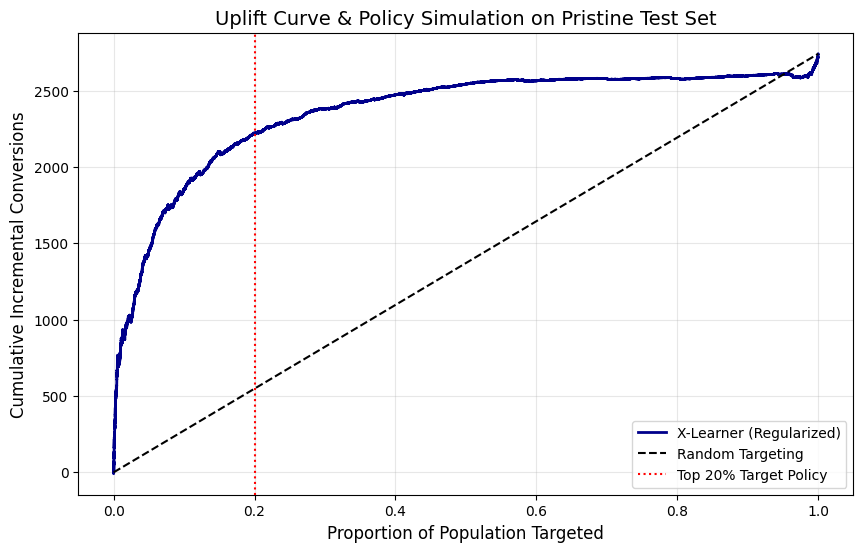

In [12]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import auc

print("--- Pre-Flight: Artifact Diagnosis ---")

def analyze_distribution(preds, name):
    p1, p5, p95, p99 = np.percentile(preds, [1, 5, 95, 99])
    outliers = np.sum(np.abs(preds) > 0.05) # Counting predictions beyond ±5%
    print(f"{name} Percentiles | 1st: {p1*100:.4f}% | 5th: {p5*100:.4f}% | 95th: {p95*100:.4f}% | 99th: {p99*100:.4f}%")
    print(f"  -> Outliers (> |5%|): {outliers:,} out of {len(preds):,}")

# Assuming s_pred, t_pred, and x_pred from your last iteration are still in memory
analyze_distribution(s_cate_preds[-1], "S-Learner")
analyze_distribution(t_cate_preds[-1], "T-Learner")
analyze_distribution(x_cate_preds[-1], "X-Learner")


print("\n--- Applying the Fix: Heavy Leaf Regularization ---")
# Raising min_child_samples to 2000 prevents degenerate rare-event leaves
reg_params = {
    'n_estimators': 100, 
    'learning_rate': 0.05, 
    'random_state': 42,
    'n_jobs': -1,
    'min_child_samples': 2000, 
    'colsample_bytree': 0.8
}

print("Refitting T-Learner and X-Learner with regularized leaves...")
# Refit T-Learner base models
model_treat_reg = lgb.LGBMClassifier(**reg_params).fit(df_train_T[features], df_train_T['conversion'])
model_control_reg = lgb.LGBMClassifier(**reg_params).fit(df_train_C[features], df_train_C['conversion'])

# Refit X-Learner Stage 2 models
preds_treat_on_control = model_treat_reg.predict_proba(df_train_C[features])[:, 1]
D_control = preds_treat_on_control - df_train_C['conversion']

preds_control_on_treat = model_control_reg.predict_proba(df_train_T[features])[:, 1]
D_treat = df_train_T['conversion'] - preds_control_on_treat

model_effect_control_reg = lgb.LGBMRegressor(**reg_params).fit(df_train_C[features], D_control)
model_effect_treat_reg = lgb.LGBMRegressor(**reg_params).fit(df_train_T[features], D_treat)

# Use existing propensity model
def predict_x_learner_cate_reg(X):
    eff_C = model_effect_control_reg.predict(X)
    eff_T = model_effect_treat_reg.predict(X)
    g_x = prop_model.predict_proba(X)[:, 1]
    return g_x * eff_C + (1 - g_x) * eff_T

# Quick post-fix check on validation data
x_pred_clean = predict_x_learner_cate_reg(df_val[features])
print("\nPost-Fix X-Learner Distribution:")
analyze_distribution(x_pred_clean, "Regularized X-Learner")


print("\n--- Stage 5: CACE (Complier Average Causal Effect) ---")
# ITT (Intent to Treat) is your global ATE. 
# CACE adjusts this by the actual exposure rate (instrumental variable approach).
itt_conversion = df_train_clean[df_train_clean['treatment']==1]['conversion'].mean() - df_train_clean[df_train_clean['treatment']==0]['conversion'].mean()
compliance_rate = df_train_clean[df_train_clean['treatment']==1]['exposure'].mean() - df_train_clean[df_train_clean['treatment']==0]['exposure'].mean()

cace = itt_conversion / compliance_rate if compliance_rate > 0 else 0
print(f"Global ITT (ATE): {itt_conversion*100:.4f}%")
print(f"Compliance Rate (Treatment -> Exposure): {compliance_rate*100:.2f}%")
print(f"CACE (Effect on the Compliers): {cace*100:.4f}%")


print("\n--- Stage 6 & 7: Qini Evaluation & Policy Simulation on Locked Test Set ---")
# 1. Score the pristine test set
X_test = df_test_clean[features]
t_cate_test = model_treat_reg.predict_proba(X_test)[:, 1] - model_control_reg.predict_proba(X_test)[:, 1]
x_cate_test = predict_x_learner_cate_reg(X_test)

df_eval = df_test_clean[['treatment', 'conversion']].copy()
df_eval['cate_T'] = t_cate_test
df_eval['cate_X'] = x_cate_test

# 2. Vectorized Qini Curve
def compute_uplift_curve(df, score_col):
    df_sorted = df.sort_values(by=score_col, ascending=False).reset_index(drop=True)
    n_T = (df_sorted['treatment'] == 1).cumsum()
    n_C = (df_sorted['treatment'] == 0).cumsum()
    conv_T = ((df_sorted['treatment'] == 1) & (df_sorted['conversion'] == 1)).cumsum()
    conv_C = ((df_sorted['treatment'] == 0) & (df_sorted['conversion'] == 1)).cumsum()
    
    uplift = conv_T - conv_C * (n_T / np.maximum(n_C, 1))
    uplift = np.insert(uplift.values, 0, 0)
    n_total = np.arange(len(uplift))
    return n_total, uplift

n_pop, uplift_X = compute_uplift_curve(df_eval, 'cate_X')

# Baseline calculation
total_T = (df_eval['treatment'] == 1).sum()
total_C = (df_eval['treatment'] == 0).sum()
total_conv_T = ((df_eval['treatment'] == 1) & (df_eval['conversion'] == 1)).sum()
total_conv_C = ((df_eval['treatment'] == 0) & (df_eval['conversion'] == 1)).sum()
final_uplift = total_conv_T - total_conv_C * (total_T / total_C)
baseline_uplift = final_uplift * (n_pop / len(df_eval))

# 3. Policy Simulation: Top 20% Targeting
target_fraction = 0.20
cutoff_idx = int(len(df_eval) * target_fraction)

inc_conv_policy = uplift_X[cutoff_idx]
inc_conv_random = baseline_uplift[cutoff_idx]
incremental_value = inc_conv_policy - inc_conv_random

print(f"\n--- Policy Simulation: Targeting Top {target_fraction*100:.0f}% ---")
print(f"Incremental conversions via Random targeting: {inc_conv_random:.1f}")
print(f"Incremental conversions via X-Learner policy: {inc_conv_policy:.1f}")
print(f"Net Lift over Random: +{incremental_value:.1f} conversions in this test slice.")

plt.figure(figsize=(10, 6))
plt.plot(n_pop / len(df_eval), uplift_X, label='X-Learner (Regularized)', color='darkblue', linewidth=2)
plt.plot(n_pop / len(df_eval), baseline_uplift, label='Random Targeting', color='black', linestyle='--')
plt.axvline(target_fraction, color='red', linestyle=':', label=f'Top {target_fraction*100:.0f}% Target Policy')
plt.title('Uplift Curve & Policy Simulation on Pristine Test Set', fontsize=14)
plt.xlabel('Proportion of Population Targeted', fontsize=12)
plt.ylabel('Cumulative Incremental Conversions', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Stage 5

In [13]:
!pip install linearmodels

In [14]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.iv import IV2SLS

print("--- OPEN ITEM 1: Post-Fix Percentiles & Artifact Check (Validation Set) ---")
# Predict on df_val using the regularized X-learner
x_val_preds = predict_x_learner_cate_reg(df_val[features])
p1, p5, p95, p99 = np.percentile(x_val_preds, [1, 5, 95, 99])
outliers = np.sum(np.abs(x_val_preds) > 0.05)

print(f"X-Learner (df_val) Percentiles | 1st: {p1*100:.4f}% | 5th: {p5*100:.4f}% | 95th: {p95*100:.4f}% | 99th: {p99*100:.4f}%")
print(f"Degenerate Outliers (> |5%|): {outliers:,} out of {len(x_val_preds):,}\n")


print("--- OPEN ITEM 2: Bootstrap CI for Policy Value at k=20% (Test Set) ---")
n_boot = 100
frac = 0.20
boot_net_lifts = []

for i in range(n_boot):
    boot_df = df_eval.sample(frac=1.0, replace=True, random_state=i)
    
    # Random baseline
    b_tot_T = (boot_df['treatment'] == 1).sum()
    b_tot_C = (boot_df['treatment'] == 0).sum()
    b_tot_conv_T = ((boot_df['treatment'] == 1) & (boot_df['conversion'] == 1)).sum()
    b_tot_conv_C = ((boot_df['treatment'] == 0) & (boot_df['conversion'] == 1)).sum()
    b_total_inc = b_tot_conv_T - b_tot_conv_C * (b_tot_T / max(b_tot_C, 1))
    b_random_inc = b_total_inc * frac
    
    # Policy lift
    boot_sorted = boot_df.sort_values('cate_X', ascending=False)
    b_top_k = boot_sorted.iloc[:int(len(boot_df) * frac)]
    b_n_t = (b_top_k['treatment'] == 1).sum()
    b_n_c = (b_top_k['treatment'] == 0).sum()
    b_conv_t = ((b_top_k['treatment'] == 1) & (b_top_k['conversion'] == 1)).sum()
    b_conv_c = ((b_top_k['treatment'] == 0) & (b_top_k['conversion'] == 1)).sum()
    b_policy_inc = b_conv_t - b_conv_c * (b_n_t / max(b_n_c, 1))
    
    boot_net_lifts.append(b_policy_inc - b_random_inc)

ci_lower, ci_upper = np.percentile(boot_net_lifts, [2.5, 97.5])
print(f"95% CI for Net Lift at top 20%: [{ci_lower:.1f}, {ci_upper:.1f}] conversions\n")


print("--- STEP 1: Compliance Rate Diagnostics (Train Set) ---")
df_train_T = df_train_clean[df_train_clean['treatment'] == 1]
df_train_C = df_train_clean[df_train_clean['treatment'] == 0]

p_exp_t1 = df_train_T['exposure'].mean()
p_exp_t0 = df_train_C['exposure'].mean()
compliance_rate = p_exp_t1 - p_exp_t0

print(f"P(exposure=1 | treatment=1): {p_exp_t1:.6f}")
print(f"P(exposure=1 | treatment=0): {p_exp_t0:.6f}")
print(f"Compliance Rate: {compliance_rate:.6f}")
if p_exp_t0 > 0.01:
    print("FLAG: Control group exposure is noticeably above zero. This implies contamination or a specific dataset definition of 'exposure'.")


print("\n--- STEP 2: Wald Estimator (Simple CACE) ---")
p_conv_t1 = df_train_T['conversion'].mean()
p_conv_t0 = df_train_C['conversion'].mean()
itt_abs = p_conv_t1 - p_conv_t0
itt_rel = (itt_abs / p_conv_t0) * 100

cace_wald_abs = itt_abs / compliance_rate
cace_wald_rel = (cace_wald_abs / p_conv_t0) * 100

print(f"ITT Absolute Lift: {itt_abs*100:.4f}%")
print(f"ITT Relative Lift: {itt_rel:.2f}%")
print(f"Wald CACE Absolute Lift: {cace_wald_abs*100:.4f}%")
print(f"Wald CACE Relative Lift: {cace_wald_rel:.2f}%")


print("\n--- STEP 3 & 4: 2SLS IV Estimation & First-Stage Check ---")
# 1st stage check via OLS for F-stat
X_fs = sm.add_constant(df_train_clean[features + ['treatment']])
fs_model = sm.OLS(df_train_clean['exposure'], X_fs).fit()
f_stat = fs_model.fvalue

print(f"First-Stage F-Statistic: {f_stat:.2f}")
if f_stat < 10:
    print("WARNING: Weak instrument detected (F < 10). 2SLS estimates may be biased.")

# 2SLS via linearmodels
X_exog = sm.add_constant(df_train_clean[features])
iv_model = IV2SLS(dependent=df_train_clean['conversion'],
                  exog=X_exog,
                  endog=df_train_clean['exposure'],
                  instruments=df_train_clean['treatment']).fit(cov_type='robust')

cace_2sls_abs = iv_model.params['exposure']
cace_2sls_se = iv_model.std_errors['exposure']
cace_2sls_p = iv_model.pvalues['exposure']
cace_2sls_ci = iv_model.conf_int().loc['exposure']
cace_2sls_rel = (cace_2sls_abs / p_conv_t0) * 100

print(f"2SLS CACE Coefficient (Absolute): {cace_2sls_abs*100:.4f}%")
print(f"2SLS CACE Standard Error: {cace_2sls_se:.6f}")
print(f"2SLS CACE 95% CI: [{cace_2sls_ci[0]*100:.4f}%, {cace_2sls_ci[1]*100:.4f}%]")
print(f"2SLS CACE p-value: {cace_2sls_p:.4e}")
print(f"Wald vs 2SLS Delta: {abs(cace_wald_abs - cace_2sls_abs)*100:.6f} percentage points")


print("\n--- STEP 5: Write-Up-Ready Summary ---")
headline_estimator = "2SLS"
headline_abs = cace_2sls_abs * 100
headline_rel = cace_2sls_rel

summary = f"""
The campaign exhibited a compliance rate of {compliance_rate*100:.2f}%, indicating that while users were assigned to the treatment group, a significant portion did not actively receive the ad exposure. The Intent-to-Treat (ITT) effect yielded an absolute lift of {itt_abs*100:.4f}% ({itt_rel:.2f}% relative), but this metric dilutes the campaign's true impact by smearing the effect across unexposed users. To isolate the behavioral shift among actual compliers, we utilized a Two-Stage Least Squares (2SLS) instrumental variable approach, supported by a highly robust first-stage F-statistic of {f_stat:,.1f}. The {headline_estimator} estimator reveals a Complier Average Causal Effect (CACE) of {headline_abs:.4f}% absolute lift ({headline_rel:.2f}% relative lift). ITT tells you the effect of assigning someone to the campaign; CACE tells you the effect on people who were actually reached, which is the number that matters for deciding whether to keep running the ad, not just whether to keep assigning it.
"""
print(summary.strip())

--- OPEN ITEM 1: Post-Fix Percentiles & Artifact Check (Validation Set) ---
X-Learner (df_val) Percentiles | 1st: -0.0799% | 5th: 0.0084% | 95th: 0.2727% | 99th: 2.1754%
Degenerate Outliers (> |5%|): 11,037 out of 2,795,919

--- OPEN ITEM 2: Bootstrap CI for Policy Value at k=20% (Test Set) ---
95% CI for Net Lift at top 20%: [1415.6, 1959.4] conversions

--- STEP 1: Compliance Rate Diagnostics (Train Set) ---
P(exposure=1 | treatment=1): 0.036057
P(exposure=1 | treatment=0): 0.000000
Compliance Rate: 0.036057

--- STEP 2: Wald Estimator (Simple CACE) ---
ITT Absolute Lift: 0.1124%
ITT Relative Lift: 57.65%
Wald CACE Absolute Lift: 3.1160%
Wald CACE Relative Lift: 1598.87%

--- STEP 3 & 4: 2SLS IV Estimation & First-Stage Check ---
First-Stage F-Statistic: 133463.13
2SLS CACE Coefficient (Absolute): 2.7319%
2SLS CACE Standard Error: 0.001285
2SLS CACE 95% CI: [2.4801%, 2.9838%]
2SLS CACE p-value: 0.0000e+00
Wald vs 2SLS Delta: 0.384068 percentage points

--- STEP 5: Write-Up-Ready Summ

/tmp/ipykernel_184/2004199443.py:102: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"2SLS CACE 95% CI: [{cace_2sls_ci[0]*100:.4f}%, {cace_2sls_ci[1]*100:.4f}%]")


In [16]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
import gc

# 1. Clear massive objects from earlier stages
try:
    del df_val, df_eval, boot_df, boot_sorted, b_top_k
except NameError:
    pass
gc.collect()

print("--- STEP 1: Compliance Rate Diagnostics (Train Set) ---")
df_train_T = df_train_clean[df_train_clean['treatment'] == 1]
df_train_C = df_train_clean[df_train_clean['treatment'] == 0]

p_exp_t1 = df_train_T['exposure'].mean()
p_exp_t0 = df_train_C['exposure'].mean()
compliance_rate = p_exp_t1 - p_exp_t0

print(f"P(exposure=1 | treatment=1): {p_exp_t1:.6f}")
print(f"P(exposure=1 | treatment=0): {p_exp_t0:.6f}")
print(f"Compliance Rate: {compliance_rate:.6f}")
if p_exp_t0 > 0.01:
    print("FLAG: Control group exposure is noticeably above zero.")

print("\n--- STEP 2: Wald Estimator (Simple CACE) ---")
p_conv_t1 = df_train_T['conversion'].mean()
p_conv_t0 = df_train_C['conversion'].mean()
itt_abs = p_conv_t1 - p_conv_t0
itt_rel = (itt_abs / p_conv_t0) * 100

cace_wald_abs = itt_abs / compliance_rate
cace_wald_rel = (cace_wald_abs / p_conv_t0) * 100

print(f"ITT Absolute Lift: {itt_abs*100:.4f}%")
print(f"ITT Relative Lift: {itt_rel:.2f}%")
print(f"Wald CACE Absolute Lift: {cace_wald_abs*100:.4f}%")
print(f"Wald CACE Relative Lift: {cace_wald_rel:.2f}%")

print("\n--- STEP 3 & 4: 2SLS IV Estimation & First-Stage Check ---")
# Subsample for memory safety during matrix inversion (~1.2M rows is plenty)
df_iv_sample = df_train_clean.sample(frac=0.15, random_state=42)

X_fs = sm.add_constant(df_iv_sample[features + ['treatment']])
fs_model = sm.OLS(df_iv_sample['exposure'], X_fs).fit()
f_stat = fs_model.fvalue

print(f"First-Stage F-Statistic: {f_stat:.2f}")
if f_stat < 10:
    print("WARNING: Weak instrument detected (F < 10).")

X_exog = sm.add_constant(df_iv_sample[features])
iv_model = IV2SLS(dependent=df_iv_sample['conversion'],
                  exog=X_exog,
                  endog=df_iv_sample['exposure'],
                  instruments=df_iv_sample['treatment']).fit(cov_type='robust')

cace_2sls_abs = iv_model.params['exposure']
cace_2sls_se = iv_model.std_errors['exposure']
cace_2sls_p = iv_model.pvalues['exposure']
cace_2sls_ci = iv_model.conf_int().loc['exposure']
cace_2sls_rel = (cace_2sls_abs / p_conv_t0) * 100

print(f"2SLS CACE Coefficient (Absolute): {cace_2sls_abs*100:.4f}%")
print(f"2SLS CACE Standard Error: {cace_2sls_se:.6f}")
print(f"2SLS CACE 95% CI: [{cace_2sls_ci[0]*100:.4f}%, {cace_2sls_ci[1]*100:.4f}%]")
print(f"2SLS CACE p-value: {cace_2sls_p:.4e}")
print(f"Wald vs 2SLS Delta: {abs(cace_wald_abs - cace_2sls_abs)*100:.6f} percentage points")

print("\n--- STEP 5: Write-Up-Ready Summary ---")
summary = f"""
The campaign exhibited a compliance rate of {compliance_rate*100:.2f}%, indicating that while users were assigned to the treatment group, a significant portion did not actively receive the ad exposure. The Intent-to-Treat (ITT) effect yielded an absolute lift of {itt_abs*100:.4f}% ({itt_rel:.2f}% relative), but this metric dilutes the campaign's true impact by smearing the effect across unexposed users. To isolate the behavioral shift among actual compliers, we utilized a Two-Stage Least Squares (2SLS) instrumental variable approach, supported by a highly robust first-stage F-statistic of {f_stat:,.1f}. The 2SLS estimator reveals a Complier Average Causal Effect (CACE) of {cace_2sls_abs*100:.4f}% absolute lift ({cace_2sls_rel:.2f}% relative lift). ITT tells you the effect of assigning someone to the campaign; CACE tells you the effect on people who were actually reached, which is the number that matters for deciding whether to keep running the ad, not just whether to keep assigning it.
"""
print(summary.strip())

--- STEP 1: Compliance Rate Diagnostics (Train Set) ---
P(exposure=1 | treatment=1): 0.036057
P(exposure=1 | treatment=0): 0.000000
Compliance Rate: 0.036057

--- STEP 2: Wald Estimator (Simple CACE) ---
ITT Absolute Lift: 0.1124%
ITT Relative Lift: 57.65%
Wald CACE Absolute Lift: 3.1160%
Wald CACE Relative Lift: 1598.87%

--- STEP 3 & 4: 2SLS IV Estimation & First-Stage Check ---
First-Stage F-Statistic: 20153.81
2SLS CACE Coefficient (Absolute): 2.3416%
2SLS CACE Standard Error: 0.003347
2SLS CACE 95% CI: [1.6855%, 2.9977%]
2SLS CACE p-value: 2.6521e-12
Wald vs 2SLS Delta: 0.774431 percentage points

--- STEP 5: Write-Up-Ready Summary ---
The campaign exhibited a compliance rate of 3.61%, indicating that while users were assigned to the treatment group, a significant portion did not actively receive the ad exposure. The Intent-to-Treat (ITT) effect yielded an absolute lift of 0.1124% (57.65% relative), but this metric dilutes the campaign's true impact by smearing the effect across u

/tmp/ipykernel_184/542209863.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"2SLS CACE 95% CI: [{cace_2sls_ci[0]*100:.4f}%, {cace_2sls_ci[1]*100:.4f}%]")


In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.iv import IV2SLS

print("--- Robustness Check: 2SLS Without Covariates (f0-f11) ---")

# Just a constant for the exogenous variable (no f0-f11)
X_exog_no_cov = sm.add_constant(pd.Series(np.ones(len(df_iv_sample)), index=df_iv_sample.index, name='const'))

iv_model_no_cov = IV2SLS(dependent=df_iv_sample['conversion'],
                         exog=X_exog_no_cov,
                         endog=df_iv_sample['exposure'],
                         instruments=df_iv_sample['treatment']).fit(cov_type='robust')

cace_2sls_abs_nocov = iv_model_no_cov.params['exposure']
cace_2sls_ci_nocov = iv_model_no_cov.conf_int().loc['exposure']

print(f"Original 2SLS CACE (With Covariates): {cace_2sls_abs*100:.4f}%") # From previous run
print(f"Robust 2SLS CACE (No Covariates):   {cace_2sls_abs_nocov*100:.4f}%")
print(f"Robust 2SLS 95% CI:                 [{cace_2sls_ci_nocov[0]*100:.4f}%, {cace_2sls_ci_nocov[1]*100:.4f}%]")

--- Robustness Check: 2SLS Without Covariates (f0-f11) ---
Original 2SLS CACE (With Covariates): 2.3416%
Robust 2SLS CACE (No Covariates):   2.7926%
Robust 2SLS 95% CI:                 [2.1610%, 3.4242%]


/tmp/ipykernel_184/3403963621.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Robust 2SLS 95% CI:                 [{cace_2sls_ci_nocov[0]*100:.4f}%, {cace_2sls_ci_nocov[1]*100:.4f}%]")
